# Heart Disease Prediction — Exploratory Data Analysis

This notebook presents an end-to-end Exploratory Data Analysis (EDA) on the Cleveland subset of the UCI Heart Disease Dataset (Dataset ID: 45). All descriptive analyses and visualizations are generated directly from the un-transformed raw dataset.

## 1. Dataset Overview

The primary objective of this project is to build machine learning models capable of predicting cardiovascular disease risk based on patient clinical features. This EDA provides baseline statistical summaries, distribution analyses, risk factor comparisons, and correlation structures across the 303 patient instances.

## 2. Dataset Source

- **Source**: UCI Machine Learning Repository
- **Dataset Name**: Heart Disease Dataset (Cleveland Subset)
- **Dataset ID**: 45
- **URL**: [https://archive.ics.uci.edu/dataset/45/heart+disease](https://archive.ics.uci.edu/dataset/45/heart+disease)
- **Acquisition**: Programmatically fetched via `ucimlrepo`

## 3. Dataset Shape and Features

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in sys.path
project_root = Path(__file__).resolve().parent.parent if '__file__' in globals() else Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Load raw dataset
data_path = project_root / "data" / "raw" / "heart_disease_uci.csv"
if not data_path.exists():
    data_path = Path("data/raw/heart_disease_uci.csv")

df = pd.read_csv(data_path)
print(f"Raw dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("Columns:", list(df.columns))

Raw dataset shape: 303 rows, 14 columns
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


## 4. Data Quality

### 4.1 Missing Values
### 4.2 Duplicate Records

In [2]:
missing = df.isnull().sum()
print("Missing Value Counts:")
print(missing[missing > 0])
print(f"Total Missing Cells: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

Missing Value Counts:
ca      4
thal    2
dtype: int64
Total Missing Cells: 6
Duplicate Rows: 0


## 5. Binary Target Definition

The original target variable `num` contains values 0 to 4. For binary classification:
- `0` -> **0** (No Heart Disease)
- `1, 2, 3, 4` -> **1** (Heart Disease Present)

In [3]:
df["target"] = df["num"].apply(lambda x: 0 if x == 0 else 1)
print("Binary Target Distribution:")
print(df["target"].value_counts().rename({0: "No Heart Disease (0)", 1: "Heart Disease Present (1)"}))

Binary Target Distribution:
target
No Heart Disease (0)         164
Heart Disease Present (1)    139
Name: count, dtype: int64


## 6. Target Distribution

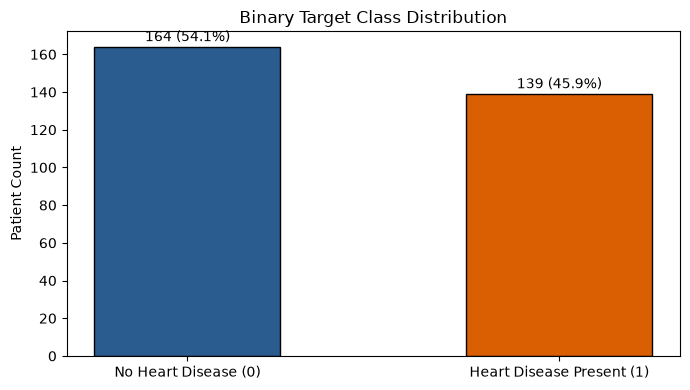

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df["target"].value_counts().sort_index()
labels = ["No Heart Disease (0)", "Heart Disease Present (1)"]
bars = ax.bar(labels, counts, color=["#2b5c8f", "#d95f02"], width=0.5, edgecolor="black")
ax.set_title("Binary Target Class Distribution")
ax.set_ylabel("Patient Count")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f"{c} ({(c/len(df))*100:.1f}%)", ha='center')
plt.tight_layout()
plt.show()

## 7. Numerical Feature Analysis

Summary statistics for continuous numerical features:
- **Age** (`age`)
- **Resting Blood Pressure** (`trestbps`)
- **Serum Cholesterol** (`chol`)
- **Maximum Heart Rate** (`thalach`)
- **ST Depression / Oldpeak** (`oldpeak`)

In [5]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 7.1 Age
### 7.2 Resting Blood Pressure
### 7.3 Cholesterol
### 7.4 Maximum Heart Rate
### 7.5 ST Depression / Oldpeak

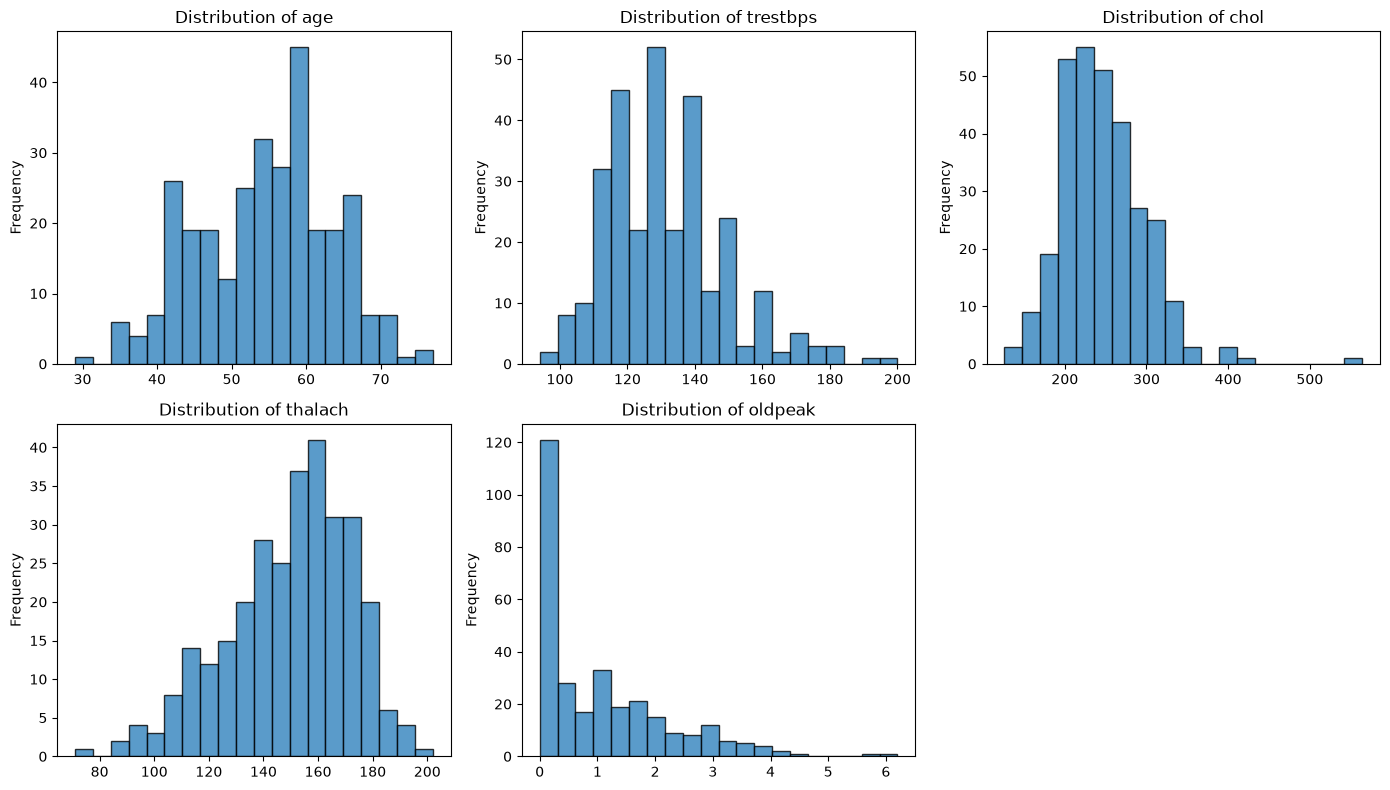

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color="#3182bd", edgecolor="black", alpha=0.8)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Frequency")

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 8. Numerical Features vs Heart Disease

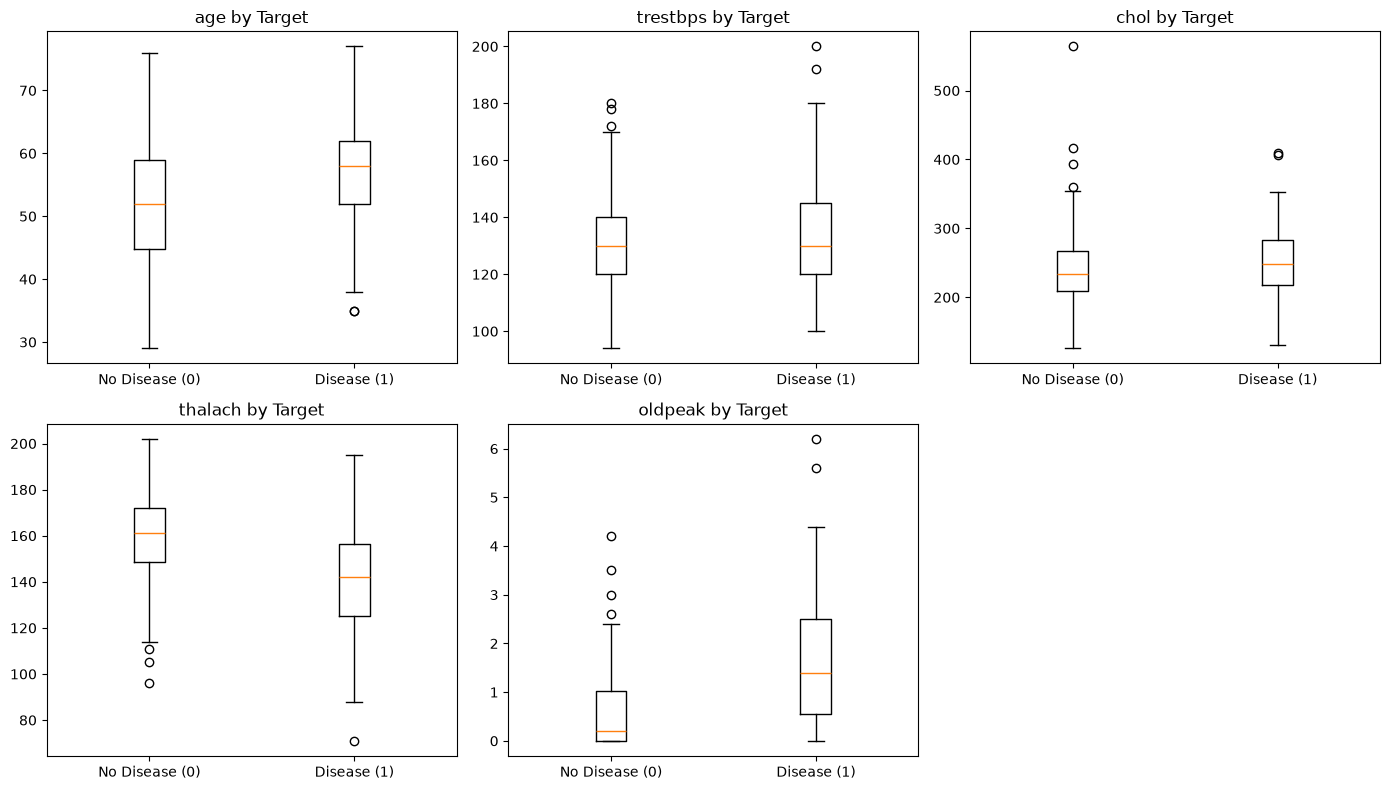

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    d0 = df[df["target"] == 0][col].dropna()
    d1 = df[df["target"] == 1][col].dropna()
    axes[i].boxplot([d0, d1], tick_labels=["No Disease (0)", "Disease (1)"])
    axes[i].set_title(f"{col} by Target")

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 9. Categorical Feature Analysis

### 9.1 Sex
### 9.2 Chest Pain Type
### 9.3 Fasting Blood Sugar
### 9.4 Resting ECG
### 9.5 Exercise-Induced Angina
### 9.6 ST Slope
### 9.7 Number of Major Vessels
### 9.8 Thal

In [8]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
for col in cat_cols:
    ct = pd.crosstab(df[col].fillna("Missing"), df["target"], margins=True)
    print(f"=== Crosstab: {col} vs Target ===")
    print(ct)
    print("\n")

=== Crosstab: sex vs Target ===
target    0    1  All
sex                  
0        72   25   97
1        92  114  206
All     164  139  303


=== Crosstab: cp vs Target ===
target    0    1  All
cp                   
1        16    7   23
2        41    9   50
3        68   18   86
4        39  105  144
All     164  139  303


=== Crosstab: fbs vs Target ===
target    0    1  All
fbs                  
0       141  117  258
1        23   22   45
All     164  139  303


=== Crosstab: restecg vs Target ===
target     0    1  All
restecg               
0         95   56  151
1          1    3    4
2         68   80  148
All      164  139  303


=== Crosstab: exang vs Target ===
target    0    1  All
exang                
0       141   63  204
1        23   76   99
All     164  139  303


=== Crosstab: slope vs Target ===
target    0    1  All
slope                
1       106   36  142
2        49   91  140
3         9   12   21
All     164  139  303


=== Crosstab: ca vs Target ===
targ

## 10. Correlation Analysis

In [9]:
corr_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
corr_df = df[corr_cols].corr()
print("Pearson Correlation Matrix:")
print(corr_df)

Pearson Correlation Matrix:
               age  trestbps      chol   thalach   oldpeak    target
age       1.000000  0.284946  0.208950 -0.393806  0.203805  0.223120
trestbps  0.284946  1.000000  0.130120 -0.045351  0.189171  0.150825
chol      0.208950  0.130120  1.000000 -0.003432  0.046564  0.085164
thalach  -0.393806 -0.045351 -0.003432  1.000000 -0.343085 -0.417167
oldpeak   0.203805  0.189171  0.046564 -0.343085  1.000000  0.424510
target    0.223120  0.150825  0.085164 -0.417167  0.424510  1.000000


## 11. Potential Outlier Analysis

In [10]:
from src.eda import generate_outlier_summary
outlier_df = generate_outlier_summary(df)
print(outlier_df.to_string(index=False))

 feature    q1    q3  iqr  lower_bound  upper_bound  outlier_count  outlier_percentage
     age  48.0  61.0 13.0        28.50        80.50              0                0.00
trestbps 120.0 140.0 20.0        90.00       170.00              9                2.97
    chol 211.0 275.0 64.0       115.00       371.00              5                1.65
 thalach 133.5 166.0 32.5        84.75       214.75              1                0.33
 oldpeak   0.0   1.6  1.6        -2.40         4.00              5                1.65


## 12. Key EDA Findings

1. **Target Ratio**: 164 No Heart Disease (54.1%) vs 139 Heart Disease Present (45.9%).
2. **Age Profile**: Mean age is higher in disease group (56.6 years) than non-disease group (52.5 years).
3. **Max Heart Rate**: Mean max heart rate is lower in disease group (139.3 bpm) than non-disease group (158.4 bpm).
4. **ST Depression**: Mean ST depression (`oldpeak`) is higher in disease group (1.57 mm) than non-disease group (0.58 mm).
5. **High Risk Categories**: Asymptomatic chest pain (cp=4, 72.7% prevalence), Exercise-induced angina (exang=1, 69.4% prevalence), and Reversible defect (thal=7.0, 76.2% prevalence) show high descriptive disease ratios.

## 13. Limitations of the EDA

- All patterns are descriptive associations within the 303 Cleveland patient observations.
- Descriptive correlation or prevalence differences do not imply medical causation.
- No feature selection or model parameter fitting was conducted based on EDA findings.
- All model preprocessing parameters remain strictly learned from the Part 3 training set.

## 14. Conclusion

The dataset provides clear, non-correlated predictor signals across patient demographics and clinical diagnostics. The repository is fully prepared for machine learning classifier benchmarking.